# Baseline Machine Learning Models

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import mne
from pathlib import Path
import warnings

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score, roc_curve
)

from data_loader import EEGDataLoader, get_default_data_path
from preprocessing import EEGPreprocessor, FeatureExtractor, create_binary_labels

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
np.random.seed(42)

## 1. Load and Preprocess Data

In [2]:
data_path = get_default_data_path()
loader = EEGDataLoader(str(data_path))

summary_df = loader.create_summary_dataframe()
block_columns = ['honest_true', 'deceitful_true', 'honest_fake', 'deceitful_fake']
complete_participants = summary_df[summary_df[block_columns].all(axis=1)]

participants_to_use = complete_participants['participant_id'].head(5).tolist()

print(f"Total participants: {len(loader.participants)}")
print(f"Complete participants (4 blocks): {len(complete_participants)}")
print(f"\nUsing {len(participants_to_use)} participants for MVP: {participants_to_use}")

Found 17 participants
Total participants: 17
Complete participants (4 blocks): 17

Using 5 participants for MVP: ['02F6BC66', '1299BF1A', '2D663E30', '4C0F44CF', '6A517891 - stare dane']


In [3]:
preprocessor = EEGPreprocessor(
    l_freq=0.5,
    h_freq=40.0,
    notch_freq=50.0,
    epoch_tmin=-0.2,
    epoch_tmax=0.8
)

feature_extractor = FeatureExtractor(sampling_freq=250.0)

In [4]:
test_participant = complete_participants.iloc[0]['participant_id']
test_data = loader.load_participant_data(test_participant)
test_block = list(test_data.keys())[0]
test_raw = test_data[test_block]

print(f"Checking {test_participant} - {test_block}")
print(f"\nAnnotations:")
print(test_raw.annotations)
print(f"\nNumber of annotations: {len(test_raw.annotations)}")

events, event_id = mne.events_from_annotations(test_raw, verbose=True)
print(f"\nEvents extracted: {len(events)}")
print(f"Event IDs: {event_id}")

if len(events) > 0:
    print(f"\nFirst few events:")
    print(events[:10])

  Loaded honest_true: 74575 samples, 21 channels, 250.0 Hz
  Loaded deceitful_true: 82275 samples, 21 channels, 250.0 Hz
  Loaded honest_fake: 79525 samples, 21 channels, 250.0 Hz
  Loaded deceitful_fake: 78625 samples, 21 channels, 250.0 Hz
Checking 02F6BC66 - honest_true

Annotations:
<Annotations | 216 segments: ParticipantResponse.NO (54), ...>

Number of annotations: 216
Used Annotations descriptions: [np.str_('ParticipantResponse.NO'), np.str_('ParticipantResponse.YES'), np.str_('PersonalDataField.BIRTH_DATE: PersonalDataType.CELEBRITY'), np.str_('PersonalDataField.BIRTH_DATE: PersonalDataType.RANDO'), np.str_('PersonalDataField.BIRTH_DATE: PersonalDataType.REAL'), np.str_('PersonalDataField.HOMETOWN: PersonalDataType.CELEBRITY'), np.str_('PersonalDataField.HOMETOWN: PersonalDataType.RANDO'), np.str_('PersonalDataField.HOMETOWN: PersonalDataType.REAL'), np.str_('PersonalDataField.NAME: PersonalDataType.CELEBRITY'), np.str_('PersonalDataField.NAME: PersonalDataType.RANDO'), np.str

In [5]:
events, event_dict = mne.events_from_annotations(test_raw, verbose=False)

print(f"\n1. All events: {len(events)} total")
print(f"   Event types: {list(event_dict.keys())[:5]}...")

stimulus_event_ids = {k: v for k, v in event_dict.items() if 'PersonalDataField' in k}
print(f"\n2. Stimulus events: {len(stimulus_event_ids)} types")
print(f"   IDs: {list(stimulus_event_ids.keys())}")

for name, id_ in list(stimulus_event_ids.items())[:3]:
    count = np.sum(events[:, 2] == id_)
    print(f"   {name}: {count} events")

print("\n3. Creating epochs...")
test_epochs_manual = mne.Epochs(test_raw, events, stimulus_event_ids,
                                tmin=-0.2, tmax=0.8,
                                baseline=(-0.2, 0),
                                reject=dict(eeg=150e-6),
                                preload=True, verbose=True)


1. All events: 216 total
   Event types: [np.str_('ParticipantResponse.NO'), np.str_('ParticipantResponse.YES'), np.str_('PersonalDataField.BIRTH_DATE: PersonalDataType.CELEBRITY'), np.str_('PersonalDataField.BIRTH_DATE: PersonalDataType.RANDO'), np.str_('PersonalDataField.BIRTH_DATE: PersonalDataType.REAL')]...

2. Stimulus events: 9 types
   IDs: [np.str_('PersonalDataField.BIRTH_DATE: PersonalDataType.CELEBRITY'), np.str_('PersonalDataField.BIRTH_DATE: PersonalDataType.RANDO'), np.str_('PersonalDataField.BIRTH_DATE: PersonalDataType.REAL'), np.str_('PersonalDataField.HOMETOWN: PersonalDataType.CELEBRITY'), np.str_('PersonalDataField.HOMETOWN: PersonalDataType.RANDO'), np.str_('PersonalDataField.HOMETOWN: PersonalDataType.REAL'), np.str_('PersonalDataField.NAME: PersonalDataType.CELEBRITY'), np.str_('PersonalDataField.NAME: PersonalDataType.RANDO'), np.str_('PersonalDataField.NAME: PersonalDataType.REAL')]
   PersonalDataField.BIRTH_DATE: PersonalDataType.CELEBRITY: 3 events
   Pers

In [6]:
print(f"\nResult: Created {len(test_epochs_manual)} epochs")
print(f"Epoch shape: {test_epochs_manual.get_data().shape}")
print(f"Event types in epochs: {list(test_epochs_manual.event_id.keys())}")


Result: Created 0 epochs
Epoch shape: (0, 21, 251)
Event types in epochs: [np.str_('PersonalDataField.BIRTH_DATE: PersonalDataType.CELEBRITY'), np.str_('PersonalDataField.BIRTH_DATE: PersonalDataType.RANDO'), np.str_('PersonalDataField.BIRTH_DATE: PersonalDataType.REAL'), np.str_('PersonalDataField.HOMETOWN: PersonalDataType.CELEBRITY'), np.str_('PersonalDataField.HOMETOWN: PersonalDataType.RANDO'), np.str_('PersonalDataField.HOMETOWN: PersonalDataType.REAL'), np.str_('PersonalDataField.NAME: PersonalDataType.CELEBRITY'), np.str_('PersonalDataField.NAME: PersonalDataType.RANDO'), np.str_('PersonalDataField.NAME: PersonalDataType.REAL')]


In [7]:
test_epochs_no_reject = mne.Epochs(test_raw, events, stimulus_event_ids,
                                    tmin=-0.2, tmax=0.8,
                                    baseline=(-0.2, 0),
                                    reject=None,
                                    preload=True, verbose=False)
print(f"Created {len(test_epochs_no_reject)} epochs without rejection!")

if len(test_epochs_no_reject) > 0:
    data = test_epochs_no_reject.get_data() * 1e6
    print(f"Data range: {np.min(data):.1f} to {np.max(data):.1f} µV")
    print(f"Mean amplitude: {np.mean(np.abs(data)):.1f} µV")

Created 108 epochs without rejection!
Data range: -1246924786.0 to 74513000000.0 µV
Mean amplitude: 1863435357.3 µV


In [8]:
print("Testing filtering...")
test_raw_filtered = preprocessor.filter_raw(test_raw, copy=True)
print("Filtering complete!")

data_filtered = test_raw_filtered.get_data() * 1e6
print(f"Filtered data range: {np.min(data_filtered):.1f} to {np.max(data_filtered):.1f} µV")
print(f"Mean amplitude: {np.mean(np.abs(data_filtered)):.1f} µV")

print("\nCreating epochs from filtered data...")
test_epochs_filtered = mne.Epochs(test_raw_filtered, events, stimulus_event_ids,
                                   tmin=-0.2, tmax=0.8,
                                   baseline=(-0.2, 0),
                                   reject=dict(eeg=500e-6),
                                   preload=True, verbose=False)
print(f"Created {len(test_epochs_filtered)} epochs with 500µV rejection threshold")

Testing filtering...
Filtering complete!
Filtered data range: -1956528902.1 to 74574000000.0 µV
Mean amplitude: 1790746818.5 µV

Creating epochs from filtered data...
Created 0 epochs with 500µV rejection threshold


In [9]:
print("Manually running pipeline steps with verbose...")
raw_filt = preprocessor.filter_raw(test_raw, copy=True)
print("Filtering done")

events_test, event_dict_test = mne.events_from_annotations(raw_filt, verbose=False)
stimulus_ids = {k: v for k, v in event_dict_test.items() if 'PersonalDataField' in k}
print(f"Found {len(stimulus_ids)} stimulus event types")
print(f"Total events: {len(events_test)}")

print("\nCreating epochs...")
epochs_test = mne.Epochs(raw_filt, events_test, stimulus_ids,
                         tmin=-0.2, tmax=0.8,
                         baseline=(-0.2, 0),
                         reject=None,
                         preload=True, verbose=True)
print(f"\nResult: {len(epochs_test)} epochs")

Manually running pipeline steps with verbose...
Filtering done
Found 9 stimulus event types
Total events: 216

Creating epochs...
Not setting metadata
108 matching events found
Applying baseline correction (mode: mean)
0 projection items activated
Using data from preloaded Raw for 108 events and 251 original time points ...
0 bad epochs dropped

Result: 108 epochs


In [10]:
pipeline_epochs = preprocessor.preprocess_pipeline(test_raw)
print(f"Returned: {len(pipeline_epochs)} epochs")
print(f"Events shape: {pipeline_epochs.events.shape}")
print(f"Event IDs: {list(pipeline_epochs.event_id.keys())[:3]}...")

  Created 108 epochs from 108 events
Returned: 108 epochs
Events shape: (108, 3)
Event IDs: [np.str_('PersonalDataField.BIRTH_DATE: PersonalDataType.CELEBRITY'), np.str_('PersonalDataField.BIRTH_DATE: PersonalDataType.RANDO'), np.str_('PersonalDataField.BIRTH_DATE: PersonalDataType.REAL')]...


In [11]:
import importlib
import preprocessing
importlib.reload(preprocessing)

preprocessor_new = preprocessing.EEGPreprocessor()
feature_extractor_new = preprocessing.FeatureExtractor()

print("Testing with preprocessor...")
new_epochs = preprocessor_new.preprocess_pipeline(test_raw)
print(f"\nResult: {len(new_epochs)} epochs!")

if len(new_epochs) > 0:
    features = feature_extractor_new.extract_combined_features(new_epochs)
    print(f"Features extracted: {features.shape}")

Testing with preprocessor...
  Created 108 epochs from 108 events

Result: 108 epochs!
  Extracted features: 252 features per epoch
Features extracted: (108, 252)


In [12]:
import importlib
import preprocessing
importlib.reload(preprocessing)

preprocessor = preprocessing.EEGPreprocessor()
feature_extractor = preprocessing.FeatureExtractor()

all_features = []
all_labels = []
all_participants_ids = []

for participant_id in participants_to_use:
    print(f"\nProcessing {participant_id}...")
    
    try:
        participant_data = loader.load_participant_data(participant_id)
        
        for block_name, raw in participant_data.items():
            print(f"  Block: {block_name}")
            
            epochs = preprocessor.preprocess_pipeline(raw)
            
            if len(epochs) == 0:
                print(f"    No valid epochs, skipping")
                continue
            
            features = feature_extractor.extract_combined_features(epochs)
            
            is_deceitful = 'deceitful' in block_name
            labels = np.ones(len(epochs)) if is_deceitful else np.zeros(len(epochs))
            
            all_features.append(features)
            all_labels.append(labels)
            all_participants_ids.extend([participant_id] * len(epochs))
            
            print(f"    {features.shape[0]} epochs, {features.shape[1]} features")
    
    except Exception as e:
        print(f"  Error: {e}")
        continue

X = np.vstack(all_features)
y = np.concatenate(all_labels)

print(f"\n{'='*60}")
print(f"DATASET CREATED")
print(f"{'='*60}")
print(f"Total epochs: {len(X)}")
print(f"Features per epoch: {X.shape[1]}")
print(f"Honest responses: {np.sum(y == 0)} ({np.sum(y == 0)/len(y)*100:.1f}%)")
print(f"Deceitful responses: {np.sum(y == 1)} ({np.sum(y == 1)/len(y)*100:.1f}%)")
print(f"{'='*60}")


Processing 02F6BC66...
  Loaded honest_true: 74575 samples, 21 channels, 250.0 Hz
  Loaded deceitful_true: 82275 samples, 21 channels, 250.0 Hz
  Loaded honest_fake: 79525 samples, 21 channels, 250.0 Hz
  Loaded deceitful_fake: 78625 samples, 21 channels, 250.0 Hz
  Block: honest_true
  Created 108 epochs from 108 events
  Extracted features: 252 features per epoch
    108 epochs, 252 features
  Block: deceitful_true
  Created 111 epochs from 111 events
  Extracted features: 252 features per epoch
    111 epochs, 252 features
  Block: honest_fake
  Created 109 epochs from 109 events
  Extracted features: 252 features per epoch
    109 epochs, 252 features
  Block: deceitful_fake
  Created 108 epochs from 108 events
  Extracted features: 252 features per epoch
    108 epochs, 252 features

Processing 1299BF1A...
  Loaded honest_true: 70175 samples, 21 channels, 250.0 Hz
  Loaded deceitful_true: 69050 samples, 21 channels, 250.0 Hz
  Loaded honest_fake: 71175 samples, 21 channels, 250.0

In [13]:
print(f"\nChecking for NaN values...")
nan_count = np.isnan(X).sum()
print(f"Total NaN values: {nan_count}")
print(f"NaN per feature (non-zero):")

if nan_count > 0:
    nan_per_feature = np.isnan(X).sum(axis=0)
    nan_features = np.where(nan_per_feature > 0)[0]
    for feat_idx in nan_features[:10]:
        print(f"  Feature {feat_idx}: {nan_per_feature[feat_idx]} NaN values")
    
    inf_count = np.isinf(X).sum()
    print(f"\nTotal Inf values: {inf_count}")
    
    print("\nCleaning data...")
    X_clean = X.copy()
    
    from sklearn.impute import SimpleImputer
    imputer = SimpleImputer(strategy='median')
    X_clean = imputer.fit_transform(X_clean)
    
    X_clean = np.nan_to_num(X_clean, nan=0.0, posinf=0.0, neginf=0.0)
    
    X = X_clean
    
    print(f"Data cleaned!")
    print(f"  Remaining NaN: {np.isnan(X).sum()}")
    print(f"  Remaining Inf: {np.isinf(X).sum()}")
else:
    print("No NaN values found!")

print(f"\nFinal dataset shape: {X.shape}")
print("="*60)


Checking for NaN values...
Total NaN values: 4414
NaN per feature (non-zero):
  Feature 155: 2207 NaN values
  Feature 156: 2207 NaN values

Total Inf values: 0

Cleaning data...
Data cleaned!
  Remaining NaN: 0
  Remaining Inf: 0

Final dataset shape: (2207, 250)


## 2. Prepare Train/Test Split

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set: {len(X_train)} samples")
print(f"Test set: {len(X_test)} samples")
print(f"\nClass distribution in training set:")
print(f"  Honest: {np.sum(y_train == 0)} ({np.sum(y_train == 0)/len(y_train)*100:.1f}%)")
print(f"  Deceitful: {np.sum(y_train == 1)} ({np.sum(y_train == 1)/len(y_train)*100:.1f}%)")

Training set: 1765 samples
Test set: 442 samples

Class distribution in training set:
  Honest: 881 (49.9%)
  Deceitful: 884 (50.1%)


In [15]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Features standardized")
print(f"Training data shape: {X_train_scaled.shape}")
print(f"Test data shape: {X_test_scaled.shape}")

Features standardized
Training data shape: (1765, 250)
Test data shape: (442, 250)


## 3. Train Models

In [16]:
models = {
    'Random Forest': RandomForestClassifier(
        n_estimators=100,
        max_depth=10,
        random_state=42,
        n_jobs=-1
    ),
    'SVM': SVC(
        kernel='rbf',
        C=1.0,
        gamma='scale',
        probability=True,
        random_state=42
    ),
    'KNN': KNeighborsClassifier(
        n_neighbors=5,
        weights='distance',
        n_jobs=-1
    )
}

print("Models defined:")
for name in models.keys():
    print(f"  - {name}")

Models defined:
  - Random Forest
  - SVM
  - KNN


In [17]:
results = {}

for name, model in models.items():
    print(f"\n{'='*60}")
    print(f"Training {name}...")
    print(f"{'='*60}")
    
    model.fit(X_train_scaled, y_train)
    
    y_pred = model.predict(X_test_scaled)
    y_pred_proba = model.predict_proba(X_test_scaled)[:, 1] if hasattr(model, 'predict_proba') else None
    
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    cv_scores = cross_val_score(model, X_train_scaled, y_train, cv=cv, scoring='accuracy')
    
    results[name] = {
        'model': model,
        'y_pred': y_pred,
        'y_pred_proba': y_pred_proba,
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'cv_mean': cv_scores.mean(),
        'cv_std': cv_scores.std()
    }
    
    print(f"\nTest Set Performance:")
    print(f"  Accuracy:  {accuracy:.4f}")
    print(f"  Precision: {precision:.4f}")
    print(f"  Recall:    {recall:.4f}")
    print(f"  F1-Score:  {f1:.4f}")
    print(f"\nCross-Validation (5-fold):")
    print(f"  Mean Accuracy: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")


Training Random Forest...

Test Set Performance:
  Accuracy:  0.8959
  Precision: 0.8788
  Recall:    0.9186
  F1-Score:  0.8982

Cross-Validation (5-fold):
  Mean Accuracy: 0.8595 (+/- 0.0138)

Training SVM...

Test Set Performance:
  Accuracy:  0.6041
  Precision: 0.5943
  Recall:    0.6561
  F1-Score:  0.6237

Cross-Validation (5-fold):
  Mean Accuracy: 0.6028 (+/- 0.0348)

Training KNN...

Test Set Performance:
  Accuracy:  0.6267
  Precision: 0.6129
  Recall:    0.6878
  F1-Score:  0.6482

Cross-Validation (5-fold):
  Mean Accuracy: 0.6391 (+/- 0.0161)


## 4. Results Comparison

In [18]:
results_df = pd.DataFrame({
    'Model': list(results.keys()),
    'Accuracy': [r['accuracy'] for r in results.values()],
    'Precision': [r['precision'] for r in results.values()],
    'Recall': [r['recall'] for r in results.values()],
    'F1-Score': [r['f1'] for r in results.values()],
    'CV Mean': [r['cv_mean'] for r in results.values()],
    'CV Std': [r['cv_std'] for r in results.values()]
})

print("\nModel Comparison:")
display(results_df.round(4))

best_model_idx = results_df['F1-Score'].idxmax()
best_model_name = results_df.loc[best_model_idx, 'Model']
print(f"\nBest model by F1-Score: {best_model_name}")


Model Comparison:


,Model,Accuracy,Precision,Recall,F1-Score,CV Mean,CV Std
0,Random Forest,0.8959,0.8788,0.9186,0.8982,0.8595,0.0138
1,SVM,0.6041,0.5943,0.6561,0.6237,0.6028,0.0348
2,KNN,0.6267,0.6129,0.6878,0.6482,0.6391,0.0161



Best model by F1-Score: Random Forest


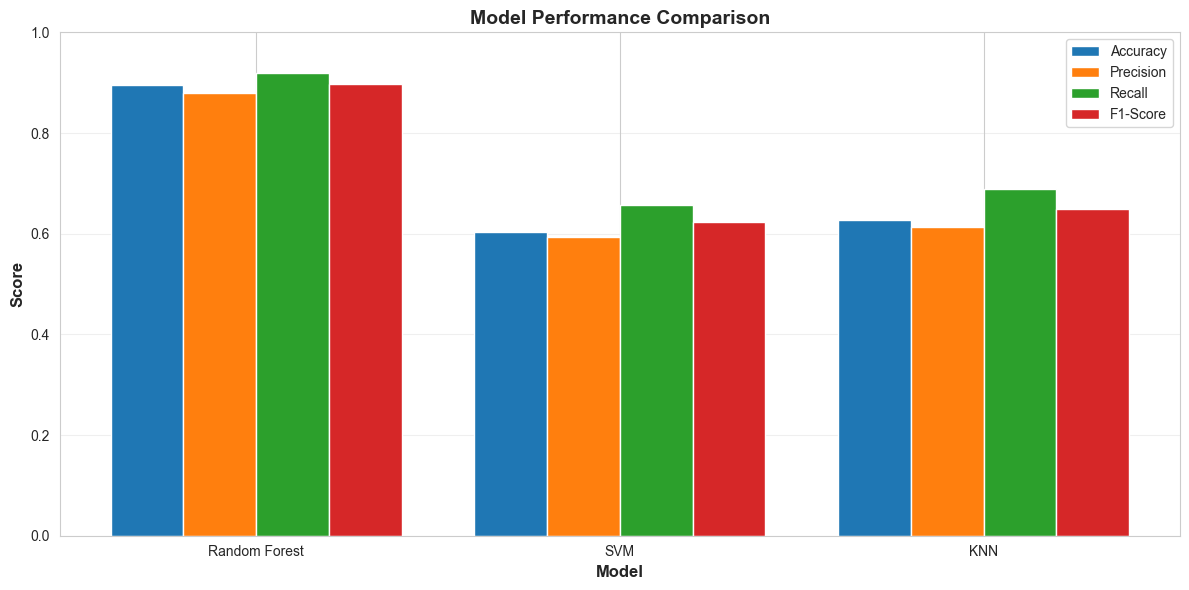

In [19]:
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
x = np.arange(len(results_df))
width = 0.2

fig, ax = plt.subplots(figsize=(12, 6))
for i, metric in enumerate(metrics):
    ax.bar(x + i*width, results_df[metric], width, label=metric)

ax.set_xlabel('Model', fontsize=12, fontweight='bold')
ax.set_ylabel('Score', fontsize=12, fontweight='bold')
ax.set_title('Model Performance Comparison', fontsize=14, fontweight='bold')
ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(results_df['Model'])
ax.legend()
ax.set_ylim([0, 1])
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## 5. Confusion Matrices

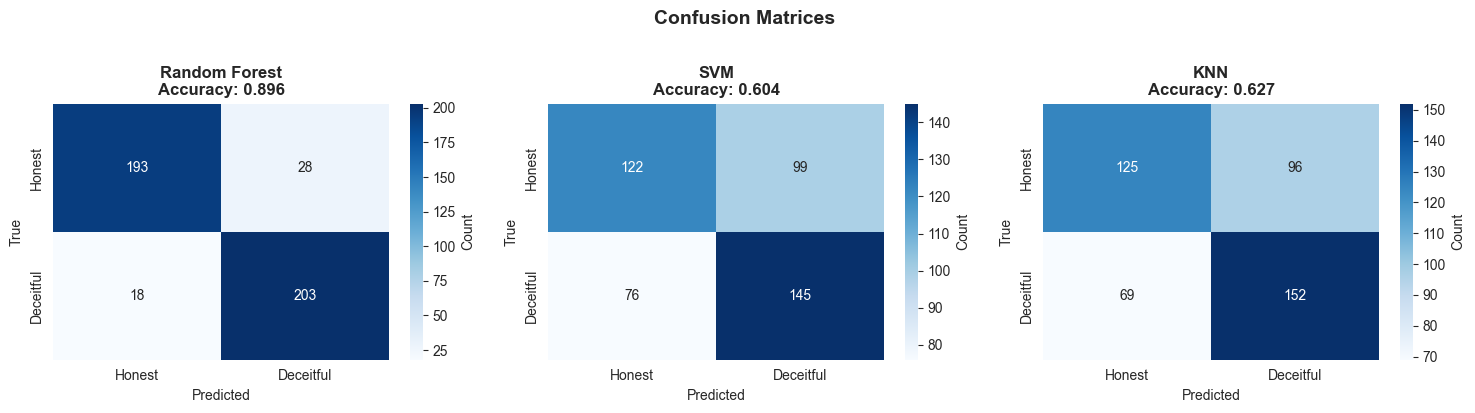

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for idx, (name, result) in enumerate(results.items()):
    cm = confusion_matrix(y_test, result['y_pred'])
    
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=['Honest', 'Deceitful'],
                yticklabels=['Honest', 'Deceitful'],
                ax=axes[idx], cbar_kws={'label': 'Count'})
    
    axes[idx].set_title(f'{name}\nAccuracy: {result["accuracy"]:.3f}', 
                       fontweight='bold')
    axes[idx].set_xlabel('Predicted')
    axes[idx].set_ylabel('True')

plt.suptitle('Confusion Matrices', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## Classification Reports

In [21]:
for name, result in results.items():
    print(f"\n{'='*60}")
    print(f"{name} - Classification Report")
    print(f"{'='*60}")
    print(classification_report(y_test, result['y_pred'], 
                               target_names=['Honest', 'Deceitful']))


Random Forest - Classification Report
              precision    recall  f1-score   support

      Honest       0.91      0.87      0.89       221
   Deceitful       0.88      0.92      0.90       221

    accuracy                           0.90       442
   macro avg       0.90      0.90      0.90       442
weighted avg       0.90      0.90      0.90       442


SVM - Classification Report
              precision    recall  f1-score   support

      Honest       0.62      0.55      0.58       221
   Deceitful       0.59      0.66      0.62       221

    accuracy                           0.60       442
   macro avg       0.61      0.60      0.60       442
weighted avg       0.61      0.60      0.60       442


KNN - Classification Report
              precision    recall  f1-score   support

      Honest       0.64      0.57      0.60       221
   Deceitful       0.61      0.69      0.65       221

    accuracy                           0.63       442
   macro avg       0.63      0.

## Random Forest

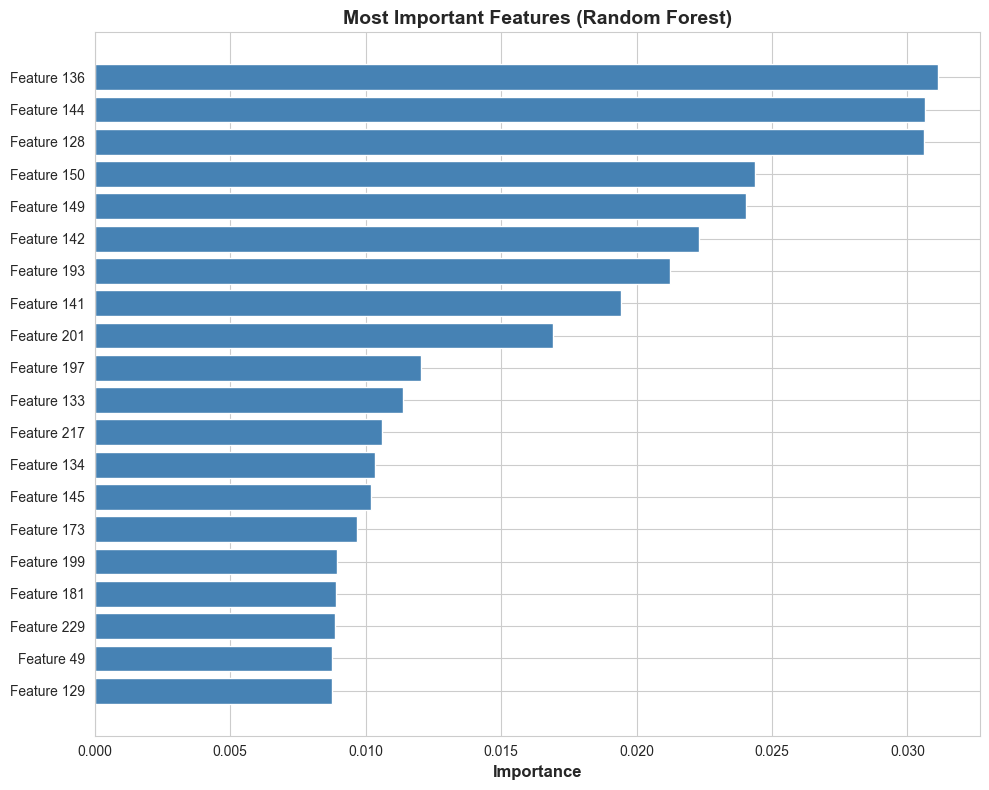


Total features: 250
Top feature importance: 0.0311


In [22]:
if 'Random Forest' in results:
    rf_model = results['Random Forest']['model']
    feature_importance = rf_model.feature_importances_
    
    top_indices = np.argsort(feature_importance)[-20:]
    top_importance = feature_importance[top_indices]
    
    plt.figure(figsize=(10, 8))
    plt.barh(range(len(top_importance)), top_importance, color='steelblue')
    plt.yticks(range(len(top_importance)), [f'Feature {i}' for i in top_indices])
    plt.xlabel('Importance', fontsize=12, fontweight='bold')
    plt.title('Most Important Features (Random Forest)', 
             fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    print(f"\nTotal features: {len(feature_importance)}")
    print(f"Top feature importance: {np.max(feature_importance):.4f}")

## Summary

In [23]:
print(f"\nDataset:")
print(f"   - Participants: {len(participants_to_use)}")
print(f"   - Total epochs: {len(X)}")
print(f"   - Features: {X.shape[1]}")
print(f"   - Train/Test: {len(X_train)}/{len(X_test)}")

print(f"\nBest Performing Model:")
best_result = results[best_model_name]
print(f"   - Model: {best_model_name}")
print(f"   - Test Accuracy: {best_result['accuracy']:.4f}")
print(f"   - F1-Score: {best_result['f1']:.4f}")
print(f"   - CV Accuracy: {best_result['cv_mean']:.4f} (+/- {best_result['cv_std']:.4f})")


Dataset:
   - Participants: 5
   - Total epochs: 2207
   - Features: 250
   - Train/Test: 1765/442

Best Performing Model:
   - Model: Random Forest
   - Test Accuracy: 0.8959
   - F1-Score: 0.8982
   - CV Accuracy: 0.8595 (+/- 0.0138)
